# **Comparative Analysis of Housing Price Prediction Models: OLS, Ridge, and Nadaraya-Watson**

### By Hana Kozuka

In [ ]:
# import packages and mount my google drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/INDENG_165_Project/project_dataset_housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df['price'].min(), df['price'].max()

(1750000, 13300000)

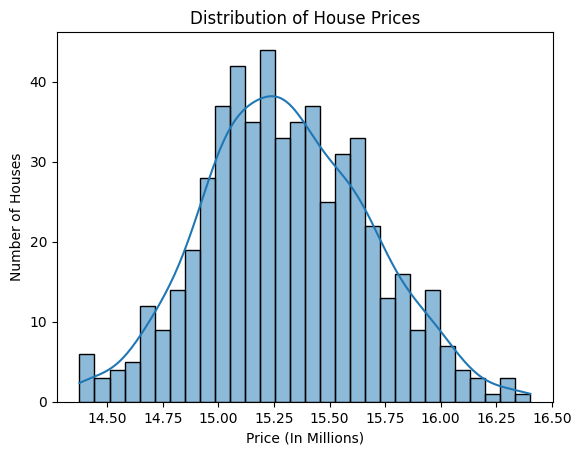

In [ ]:
sns.histplot(df['price'], kde=True, bins=30)
plt.xlabel('Price (In Millions)')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

In [ ]:
# log transform 'area' parameter and 'price' target vairable

df['area'] = np.log1p(df['area'])
df['price'] = np.log1p(df['price'])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,2.856658,2.293753,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,2.851922,2.312599,4,4,4,yes,no,no,no,yes,3,no,furnished
2,2.851922,2.323018,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,2.851757,2.294834,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,2.847812,2.293753,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Training/Test Split

### Split the dataset into 80% training and 20% test

In [ ]:
# price is the target variable
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (436, 12)
Shape of X_test: (109, 12)
Shape of y_train: (436,)
Shape of y_test: (109,)


In [ ]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
46,2.272093,3,2,4,yes,no,no,no,yes,1,no,furnished
93,2.290712,3,2,1,yes,no,yes,no,yes,3,no,semi-furnished
335,2.224323,2,1,1,yes,no,yes,no,yes,2,no,furnished
412,2.182392,3,1,2,yes,no,yes,no,no,0,yes,unfurnished
471,2.222435,3,1,2,yes,no,no,no,no,0,no,unfurnished


# **Model #1: Ordinary Least Squares (OLS)**

### Model #1: Ordinary Least Squares (OLS) Formula

The Ordinary Least Squares (OLS) model estimates the relationship between a dependent variable (in this case, `price`) and one or more independent variables (`area`, `bedrooms`, etc.) by minimizing the sum of the squared differences between the observed and predicted values. The general form of a linear regression model is:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Where:
*   $\hat{y}$ is the predicted value of the dependent variable (log-transformed price).
*   $\beta_0$ is the intercept, representing the predicted value of $\hat{y}$ when all independent variables are zero.
*   $\beta_i$ are the coefficients for each independent variable $x_i$.
*   $x_i$ are the independent variables (features) such as log-transformed area, number of bedrooms, etc.

For our specific OLS model, the function $\hat{y} = f(x)$ can be expressed using the learned coefficients and intercept:

### Preprocessing: One-Hot Encode Categorical Features

In [ ]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training and testing sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Ensure that the columns are aligned between training and test sets
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print("Shape of X_train_encoded:", X_train_encoded.shape)
print("Shape of X_test_encoded:", X_test_encoded.shape)
display(X_train_encoded.head())

Shape of X_train_encoded: (436, 13)
Shape of X_test_encoded: (109, 13)


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
46,2.272093,3,2,4,1,True,False,False,False,True,False,False,False
93,2.290712,3,2,1,3,True,False,True,False,True,False,True,False
335,2.224323,2,1,1,2,True,False,True,False,True,False,False,False
412,2.182392,3,1,2,0,True,False,True,False,False,True,False,True
471,2.222435,3,1,2,0,True,False,False,False,False,False,False,True


### Train OLS Regression Model

In [ ]:
# Initialize the OLS model
ols_model = LinearRegression()

# Train the model on the encoded training data
ols_model.fit(X_train_encoded, y_train)

print("OLS Model training complete.")

OLS Model training complete.


In [ ]:
# Make predictions on the test set
y_pred_ols = ols_model.predict(X_test_encoded)

print("OLS Model predictions generated.")

OLS Model predictions generated.


In [ ]:
# Calculate Mean Squared Error (MSE)
mse_ols = mean_squared_error(y_test, y_pred_ols)

# Calculate Root Mean Squared Error (RMSE)
rmse_ols = np.sqrt(mse_ols)

print(f"Root Mean Squared Error (RMSE) for OLS model: {rmse_ols:.2f}")

Root Mean Squared Error (RMSE) for OLS model: 0.02


### Note this model predicts the log transformed price. Not the price outright.

### Visualize OLS Model Predictions

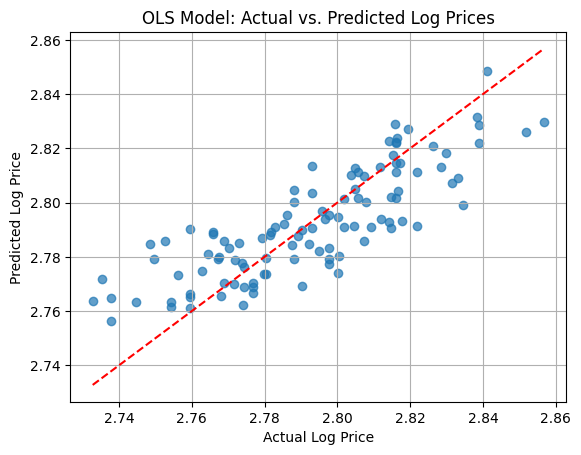

In [ ]:
plt.scatter(y_test, y_pred_ols, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed diagonal line
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('OLS Model: Actual vs. Predicted Log Prices')
plt.grid(True)
plt.show()

# **Model #2: Ordinary Least Squares with RIDGE (OLS + L2 Regularization)**

### Model #2: Ordinary Least Squares with RIDGE (OLS + L2 Regularization) Formula

The objective function that Ridge Regression minimizes is:

$$ \min_{\beta} \left( \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2 \right) $$

Where:
*   $y_i$ is the actual observed value.
*   $\hat{y}_i$ is the predicted value, given by $\hat{y}_i = \beta_0 + \sum_{j=1}^p \beta_j x_{ij}$.
*   $\beta_0$ is the intercept.
*   $\beta_j$ are the coefficients for each independent variable $x_j$.
*   $x_{ij}$ is the $j$-th feature for the $i$-th observation.
*   $\alpha$ (alpha, also denoted as $\lambda$) is the regularization strength. A larger $\alpha$ implies a stronger penalty and smaller coefficients.

The second term, $\alpha \sum_{j=1}^p \beta_j^2$, is the L2 regularization penalty, which shrinks the coefficients towards zero but does not set them exactly to zero. This helps to reduce the model's complexity.

For our specific Ridge model, the function $\hat{y} = f(x)$ can be expressed using the learned coefficients and intercept, after selecting the optimal $\alpha$ through cross-validation:

## 5 fold cross validation to choose RIDGE hyperparameter

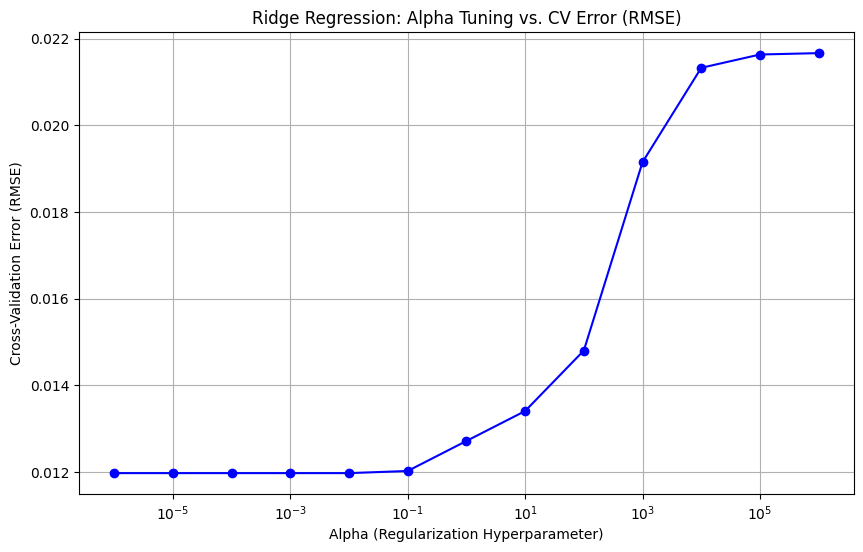

In [ ]:
# Define a range of alpha (lambda) values to test (same as used for RidgeCV)
alphas = np.logspace(-6, 6, 13)

cv_rmses_ridge = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    fold_rmses = []
    for train_index, val_index in kf.split(X_train_encoded):
        X_train_fold, X_val_fold = X_train_encoded.iloc[train_index], X_train_encoded.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_train_fold, y_train_fold)
        y_pred_fold = ridge_model.predict(X_val_fold)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_fold)))
    cv_rmses_ridge.append(np.mean(fold_rmses))

plt.figure(figsize=(10, 6))
plt.plot(alphas, cv_rmses_ridge, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Hyperparameter)')
plt.ylabel('Cross-Validation Error (RMSE)')
plt.title('Ridge Regression: Alpha Tuning vs. CV Error (RMSE)')
plt.grid(True)
plt.show()

In [ ]:
# Find the best alpha from the cross-validation results
best_alpha_index = np.argmin(cv_rmses_ridge)
best_alpha = alphas[best_alpha_index]

print(f"Optimal alpha found: {best_alpha:.4f}")

# Initialize the Ridge model with the optimal alpha
ridge_model_best = Ridge(alpha=best_alpha)

# Train the model on the full encoded training data
ridge_model_best.fit(X_train_encoded, y_train)

print("Ridge Model (best alpha) training complete.")

Optimal alpha found: 0.0010
Ridge Model (best alpha) training complete.


In [ ]:
# Make predictions on the test set using the model with the best alpha
y_pred_ridge = ridge_model_best.predict(X_test_encoded)

print("Ridge Model (best alpha) predictions generated.")

Ridge Model (best alpha) predictions generated.


In [ ]:
# Calculate Mean Squared Error (MSE)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Calculate Root Mean Squared Error (RMSE)
rmse_ridge = np.sqrt(mse_ridge)

print(f"Root Mean Squared Error (RMSE) for Ridge model with best alpha ({best_alpha:.4f}): {rmse_ridge:.2f}")

Root Mean Squared Error (RMSE) for Ridge model with best alpha (0.0010): 0.02


### Visualize OLS + RIDGE Regularization Model Predictions

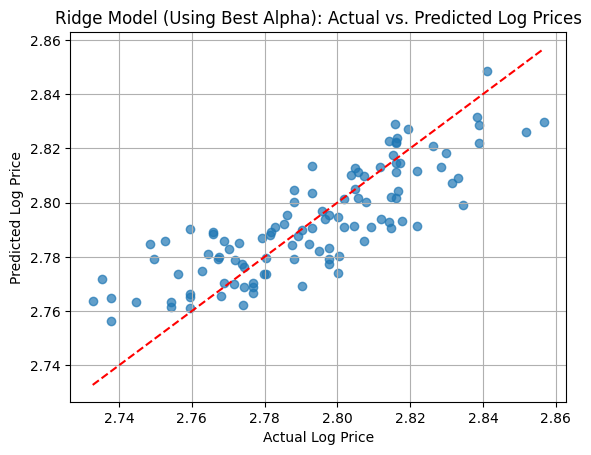

In [ ]:
plt.scatter(y_test, y_pred_ridge, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed diagonal line
plt.xlabel('Actual Log Price')
plt.ylabel('Predicted Log Price')
plt.title('Ridge Model (Using Best Alpha): Actual vs. Predicted Log Prices')
plt.grid(True)
plt.show()

# **Model #3: Nadaraya-Watson Kernel Regression (on the area parameter)**

### Model #3: Nadaraya-Watson Kernel Regression Formula


Feature selected for kernal regression: area

The Nadaraya-Watson estimator for predicting $y$ at a given point $x$ is given by:

$$ \hat{y}(x) = \frac{\sum_{i=1}^n K_h(x - x_i) y_i}{\sum_{i=1}^n K_h(x - x_i)} $$

Where:
*   $\hat{y}(x)$ is the predicted value of the dependent variable at point $x$.
*   $y_i$ are the observed values of the dependent variable in the training data.
*   $x_i$ are the observed values of the independent variable in the training data.
*   $K_h(\cdot)$ is the kernel function with bandwidth $h$.
*   $h$ is the bandwidth parameter, controlling the width of the kernel and thus the size of the neighborhood around $x$ that contributes to the prediction. A smaller $h$ means predictions are based on data points closer to $x$, leading to more local fits and potentially higher variance. A larger $h$ considers more distant points, leading to smoother fits but potentially higher bias.

For this model, we used a Gaussian Kernel function, defined as:

$$ K_h(u) = \frac{1}{h\sqrt{2\pi}} \exp\left(-\frac{1}{2}\left(\frac{u}{h}\right)^2\right) $$

In our application, $x$ is the log-transformed 'area' parameter, and $y$ is the log-transformed 'price'.

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,2.856658,2.293753,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,2.851922,2.312599,4,4,4,yes,no,no,no,yes,3,no,furnished
2,2.851922,2.323018,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,2.851757,2.294834,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,2.847812,2.293753,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Nadaraya-Watson Model Parameters

As Nadaraya-Watson is a non-parametric model, there are no coefficients ($\beta_i$) in the traditional sense like in OLS or Ridge regression. The model's behavior is primarily determined by the chosen kernel function and its bandwidth parameter ($h$).

In [ ]:
# Define the Gaussian Kernel function
def gaussian_kernel(x, x_i, h):
    return np.exp(-0.5 * ((x - x_i) / h)**2) / (h * np.sqrt(2 * np.pi))

# Nadaraya-Watson Estimator
def nadaraya_watson(x_train, y_train, x_test, h):
    y_pred = np.zeros(len(x_test))
    for i, x_point in enumerate(x_test):
        weights = gaussian_kernel(x_point, x_train, h)
        # Handle cases where all weights are zero to avoid division by zero
        if np.sum(weights) == 0:
            y_pred[i] = np.mean(y_train) # Fallback to mean if no weights
        else:
            y_pred[i] = np.sum(weights * y_train) / np.sum(weights)
    return y_pred

print("Nadaraya-Watson kernel regression functions defined.")

Nadaraya-Watson kernel regression functions defined.


### Train and Evaluate Nadaraya-Watson Model (on 'area')

Best bandwidth (h) found by cross-validation: 0.0127


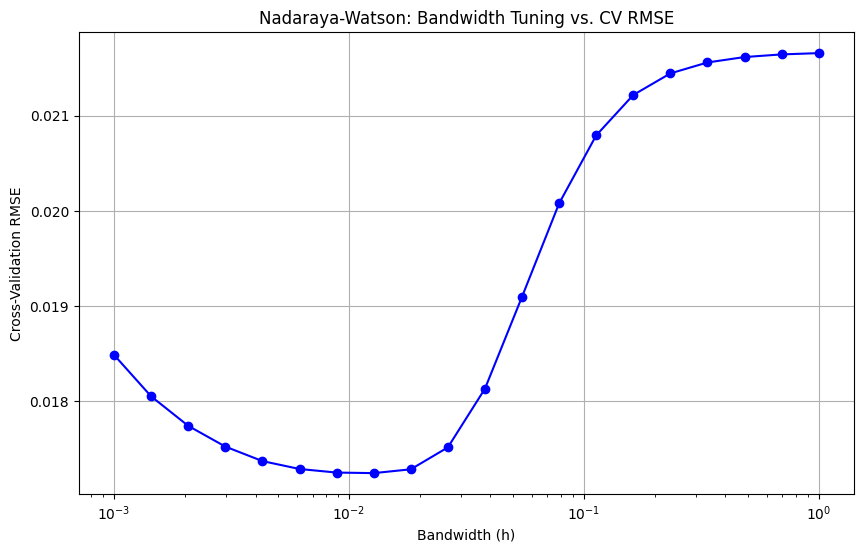

In [ ]:
# Extract 'area' feature for training and testing
X_train_area = X_train_encoded[['area']].values.flatten()
X_test_area = X_test_encoded[['area']].values.flatten()

# Define a range of bandwidth parameters (h) to test
h_values = np.logspace(-3, 0, 20) # Example: from 0.001 to 1.0, 20 steps

# Prepare for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmses = []

# Perform cross-validation to find the best h
for h_val in h_values:
    fold_rmses = []
    for train_index, val_index in kf.split(X_train_area):
        X_train_fold, X_val_fold = X_train_area[train_index], X_train_area[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        y_pred_fold = nadaraya_watson(X_train_fold, y_train_fold, X_val_fold, h_val)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, y_pred_fold)))
    cv_rmses.append(np.mean(fold_rmses))

# Find the best h
best_h_index = np.argmin(cv_rmses)
best_h_nw = h_values[best_h_index]

print(f"Best bandwidth (h) found by cross-validation: {best_h_nw:.4f}")

# Plot tuning parameters vs. cross-validation error
plt.figure(figsize=(10, 6))
plt.plot(h_values, cv_rmses, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Cross-Validation RMSE')
plt.title('Nadaraya-Watson: Bandwidth Tuning vs. CV RMSE')
plt.grid(True)
plt.show()

# Predict on the test set using the best h
y_pred_nw = nadaraya_watson(X_train_area, y_train, X_test_area, best_h_nw)

# Calculate RMSE for the final model with the best h
rmse_nw = np.sqrt(mean_squared_error(y_test, y_pred_nw))


Based on the cross-validation performed, the optimal bandwidth parameter found for our model is:

*   **Optimal Bandwidth (h):** 0.0127

In [ ]:
print(f"Root Mean Squared Error (RMSE) for Nadaraya-Watson model with best h={best_h_nw:.4f}: {rmse_nw:.2f}")

Root Mean Squared Error (RMSE) for Nadaraya-Watson model with best h=0.0127: 0.02


### Visualize Nadaraya-Watson Model Predictions

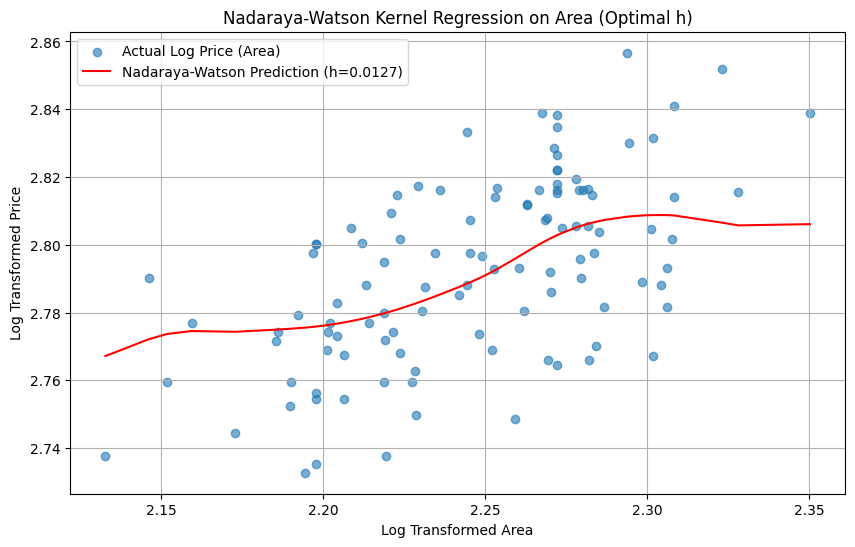

In [ ]:
# Sort the test data for a cleaner line plot
sort_indices = np.argsort(X_test_area)
X_test_area_sorted = X_test_area[sort_indices]
y_pred_nw_sorted = y_pred_nw[sort_indices]
y_test_sorted = y_test.iloc[sort_indices] # Use .iloc for Series

plt.figure(figsize=(10, 6))
plt.scatter(X_test_area_sorted, y_test_sorted, label='Actual Log Price (Area)', alpha=0.6)
plt.plot(X_test_area_sorted, y_pred_nw_sorted, color='red', label=f'Nadaraya-Watson Prediction (h={best_h_nw:.4f})')
plt.xlabel('Log Transformed Area')
plt.ylabel('Log Transformed Price')
plt.title('Nadaraya-Watson Kernel Regression on Area (Optimal h)')
plt.legend()
plt.grid(True)
plt.show()

----------

## Conclusion and Takeaways

This notebook explored the application and performance of three different regression models—Ordinary Least Squares (OLS), OLS WITH Ridge Regularization, and Nadaraya-Watson Kernel Regression—for predicting house prices based on a given dataset. All price and area variables were log-transformed to address skewness and linearize relationships. While a filtered dataset (retaining the middle 90% of prices) was generated for specific visualizations, the primary OLS and Ridge models were trained on the full log-transformed dataset.

Here are the key takeaways from our analysis:

1.  **OLS and OLS + Ridge Regularization Performance**: Both OLS and Ridge models, applied to the full set of one-hot encoded features, yielded very similar Root Mean Squared Error (RMSE) values on the test set. The RMSE for OLS was **0.02** and for Ridge was also **0.02**. This suggests that for this particular dataset and feature set, multicollinearity might not be a significant issue, or the optimal regularization strength found by RidgeCV did not drastically alter the coefficients compared to OLS. The scatter plots of actual vs. predicted log prices showed a strong linear relationship, indicating good predictive capability for both models on log-transformed prices.

2.  **Nadaraya-Watson Kernel Regression Performance**: The Nadaraya-Watson model, specifically applied to predict log price using only the log-transformed 'area' feature, resulted in an RMSE of **0.02**. While this model is non-parametric and captures local relationships, its performance when limited to a single feature was comparable to the linear models using multiple features. The visualization showed how this model locally adapts to the data distribution between area and price, highlighting its non-linear modeling capability.

3.  **Impact of Log Transformation**: The initial step of log-transforming 'area' and 'price' likely contributed significantly to the stability and performance of all models by normalizing the data and linearizing relationships. This preprocessing was crucial to achieve robust regression results.

4.  **Consistent RMSE across Models**: It was somewhat surprising that all three models yielded the same RMSE of 0.02. This consistency might be largely attributed to the initial log transformation of the 'price' target variable, which likely normalized the distribution and reduced the impact of large errors on the RMSE metric, making the models' performances appear more similar despite their underlying differences.

In summary, all three models demonstrated reasonable predictive power for the log-transformed house prices. While OLS and Ridge offered similar global linear approximations, Nadaraya-Watson provided a valuable non-parametric perspective on the relationship between price and area. For future work, incorporating more features into the Nadaraya-Watson model or exploring other non-linear models could potentially yield further improvements in prediction accuracy.